In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


plt.style.use('default')
import os
import random

# set ALL seeds before anything else
os.environ['PYTHONHASHSEED']     = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve


In [ ]:
url = "https://huggingface.co/datasets/nominal-io/nasa-turbofan-degradation/resolve/main/NASA_turbofan_train_FD001.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()



In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
id_cols = ['engine', 'cycle']

In [ ]:
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()

In [ ]:
candidate_cols = [c for c in all_numeric if c not in id_cols]

In [ ]:
setting_cols = [c for c in candidate_cols if 'setting' in c.lower()]

In [ ]:
sensor_cols  = [c for c in candidate_cols if c not in setting_cols]


In [ ]:
useful_sensors  = [c for c in sensor_cols  if df[c].std() > 0.001]
useful_settings = [c for c in setting_cols if df[c].std() > 0.001]

In [ ]:
dropped_cols = list(set(candidate_cols) - set(useful_sensors) - set(useful_settings))

In [ ]:
dropped_cols = list(set(candidate_cols) - set(useful_sensors) - set(useful_settings))
print("\ndropped (near constant):", dropped_cols)
print("kept:", len(useful_sensors), "sensors and", len(useful_settings), "settings")



dropped (near constant): ['(Fan inlet Pressure) (psia)', '(Required fan speed)', '(Required fan conversion speed)', '(Engine pressure ratio(P50/P2)', '(Burner fuel-air ratio)', 'setting_2', 'setting_3', '(Fan inlet temperature) (◦R)']
kept: 15 sensors and 1 settings


In [ ]:
feature_cols = useful_sensors + useful_settings
print("total features:", len(feature_cols))

total features: 16


In [ ]:
engine_lives = df.groupby('engine')['cycle'].max().reset_index()








In [ ]:
engine_lives = df.groupby('engine')['cycle'].max().reset_index()
engine_lives.columns = ['engine', 'max_cycle']

print("\nengine lifetime stats:")
print(engine_lives['max_cycle'].describe())




engine lifetime stats:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64


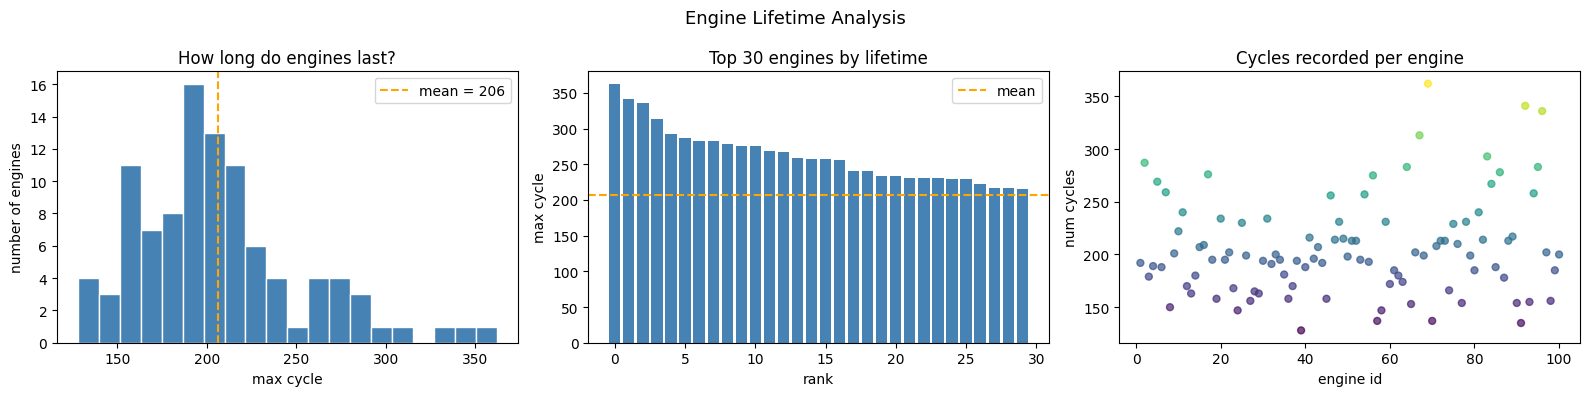


feature statistics:
                                                mean        std        min  \
(LPC outlet temperature) (◦R)             642.680934   0.500053   641.2100   
(HPC outlet temperature) (◦R)            1590.523119   6.131150  1571.0400   
(LPT outlet temperature) (◦R)            1408.933782   9.000605  1382.2500   
(bypass-duct pressure) (psia)              21.609803   0.001389    21.6000   
(HPC outlet pressure) (psia)              553.367711   0.885092   549.8500   
(Physical fan speed) (rpm)               2388.096652   0.070985  2387.9000   
(Physical core speed) (rpm)              9065.242941  22.082880  9021.7300   
(HPC outlet Static pressure) (psia)        47.541168   0.267087    46.8500   
(Ratio of fuel flow to Ps30) (pps/psia)   521.413470   0.737553   518.6900   
(Corrected fan speed) (rpm)              2388.096152   0.071919  2387.8800   
(Corrected core speed) (rpm)             8143.752722  19.076176  8099.9400   
(Bypass Ratio)                             

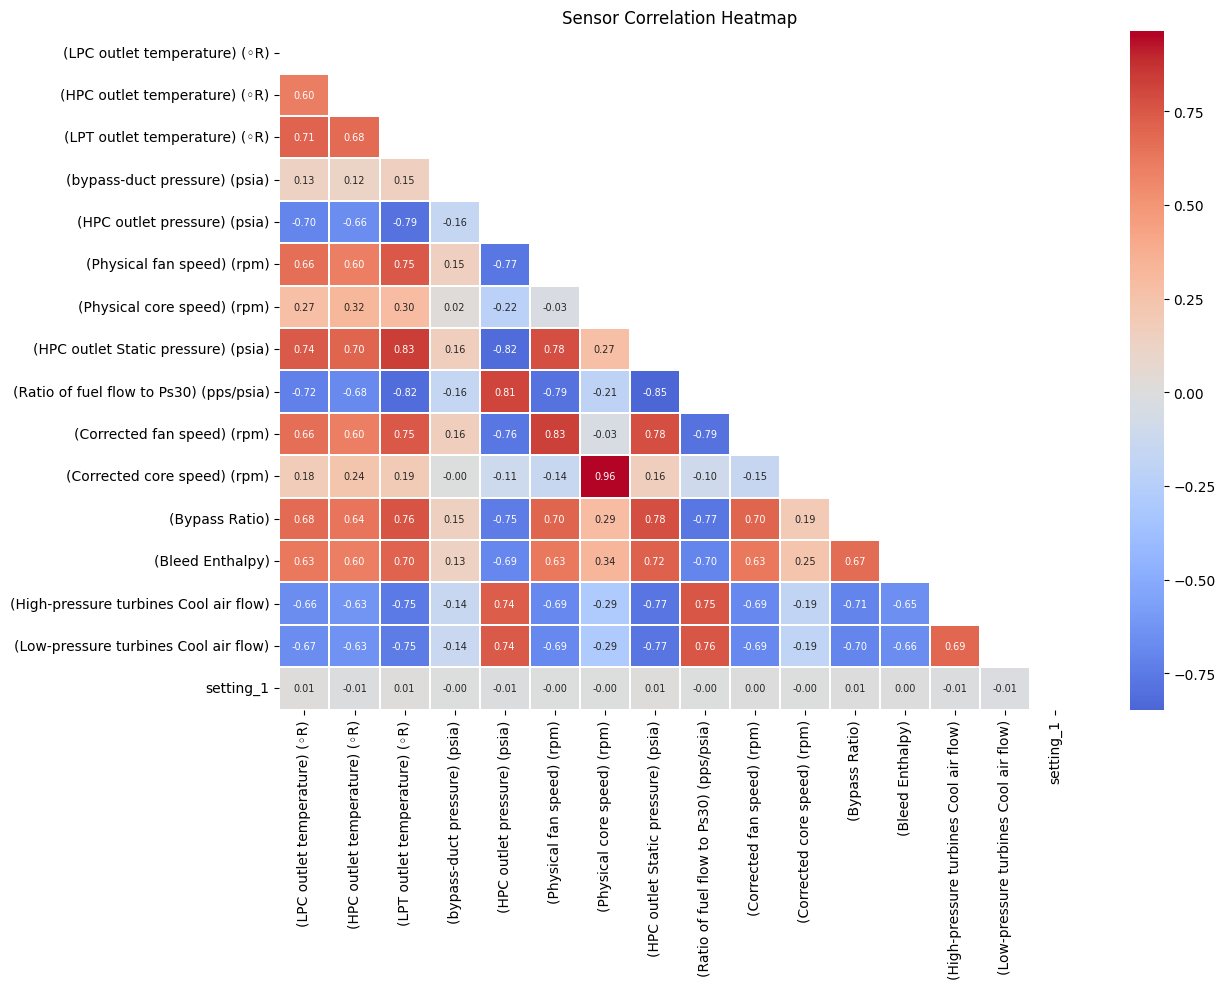

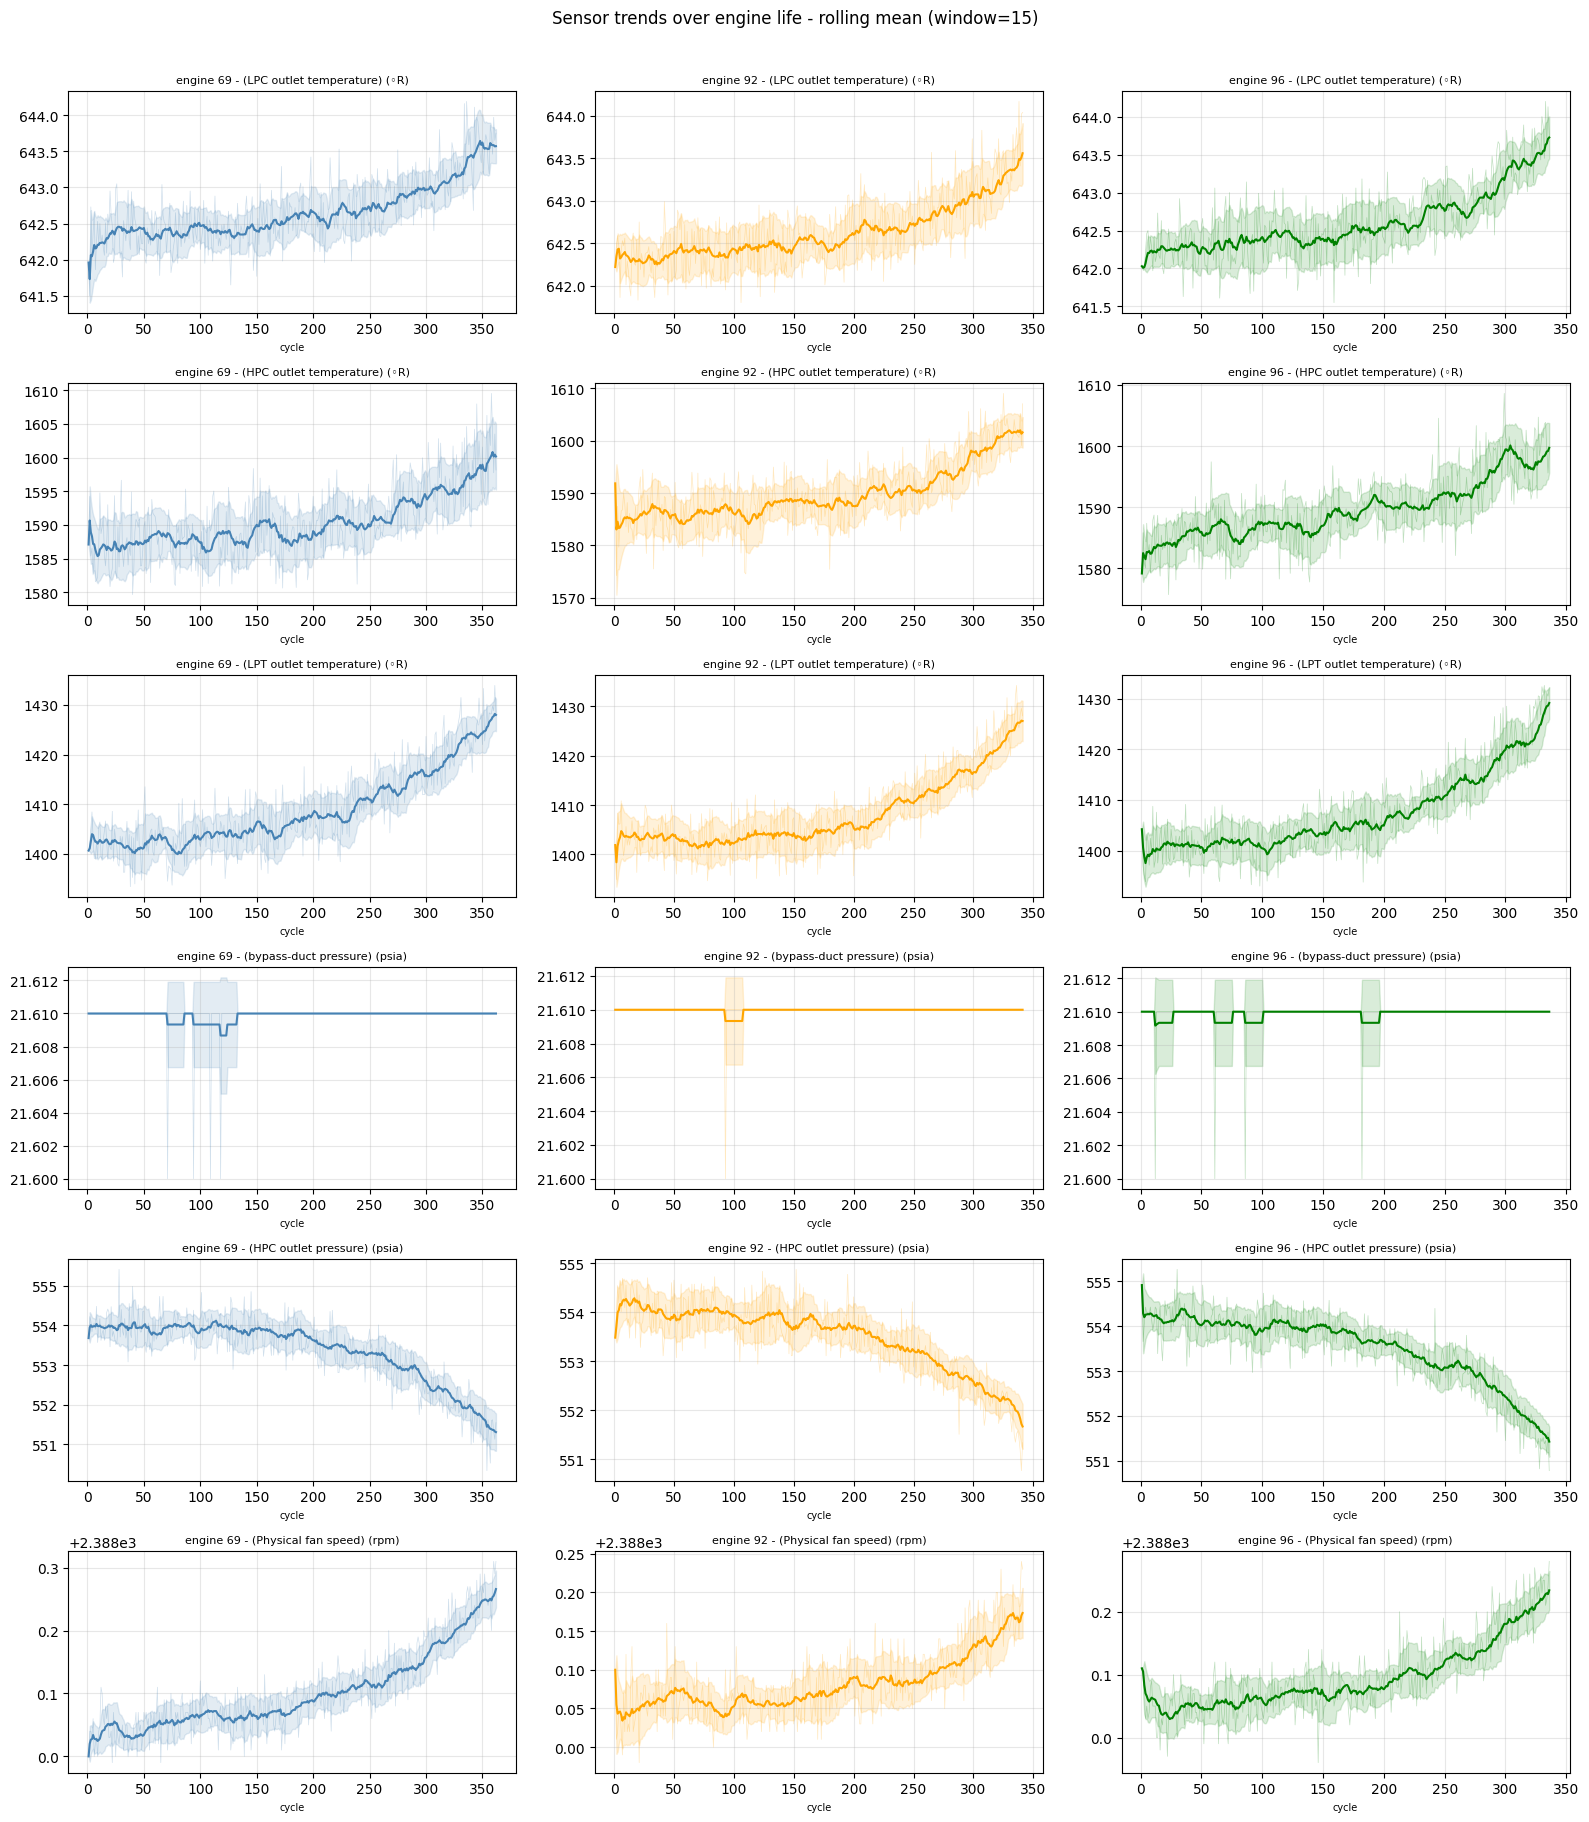


checking if sensor variance increases with age...


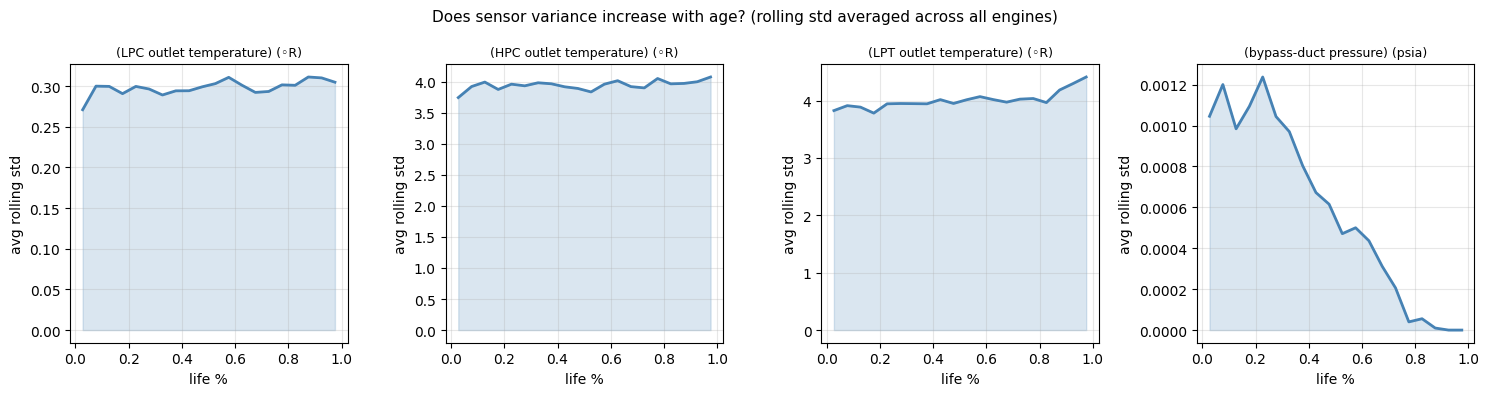

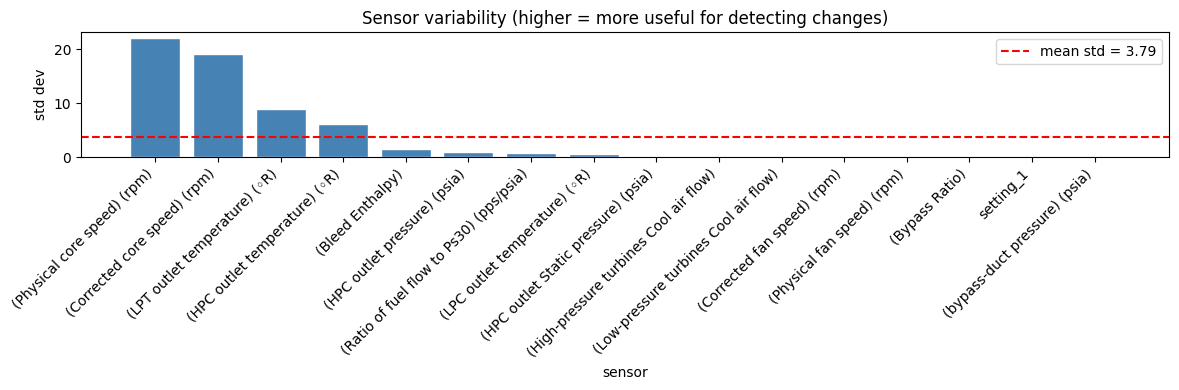

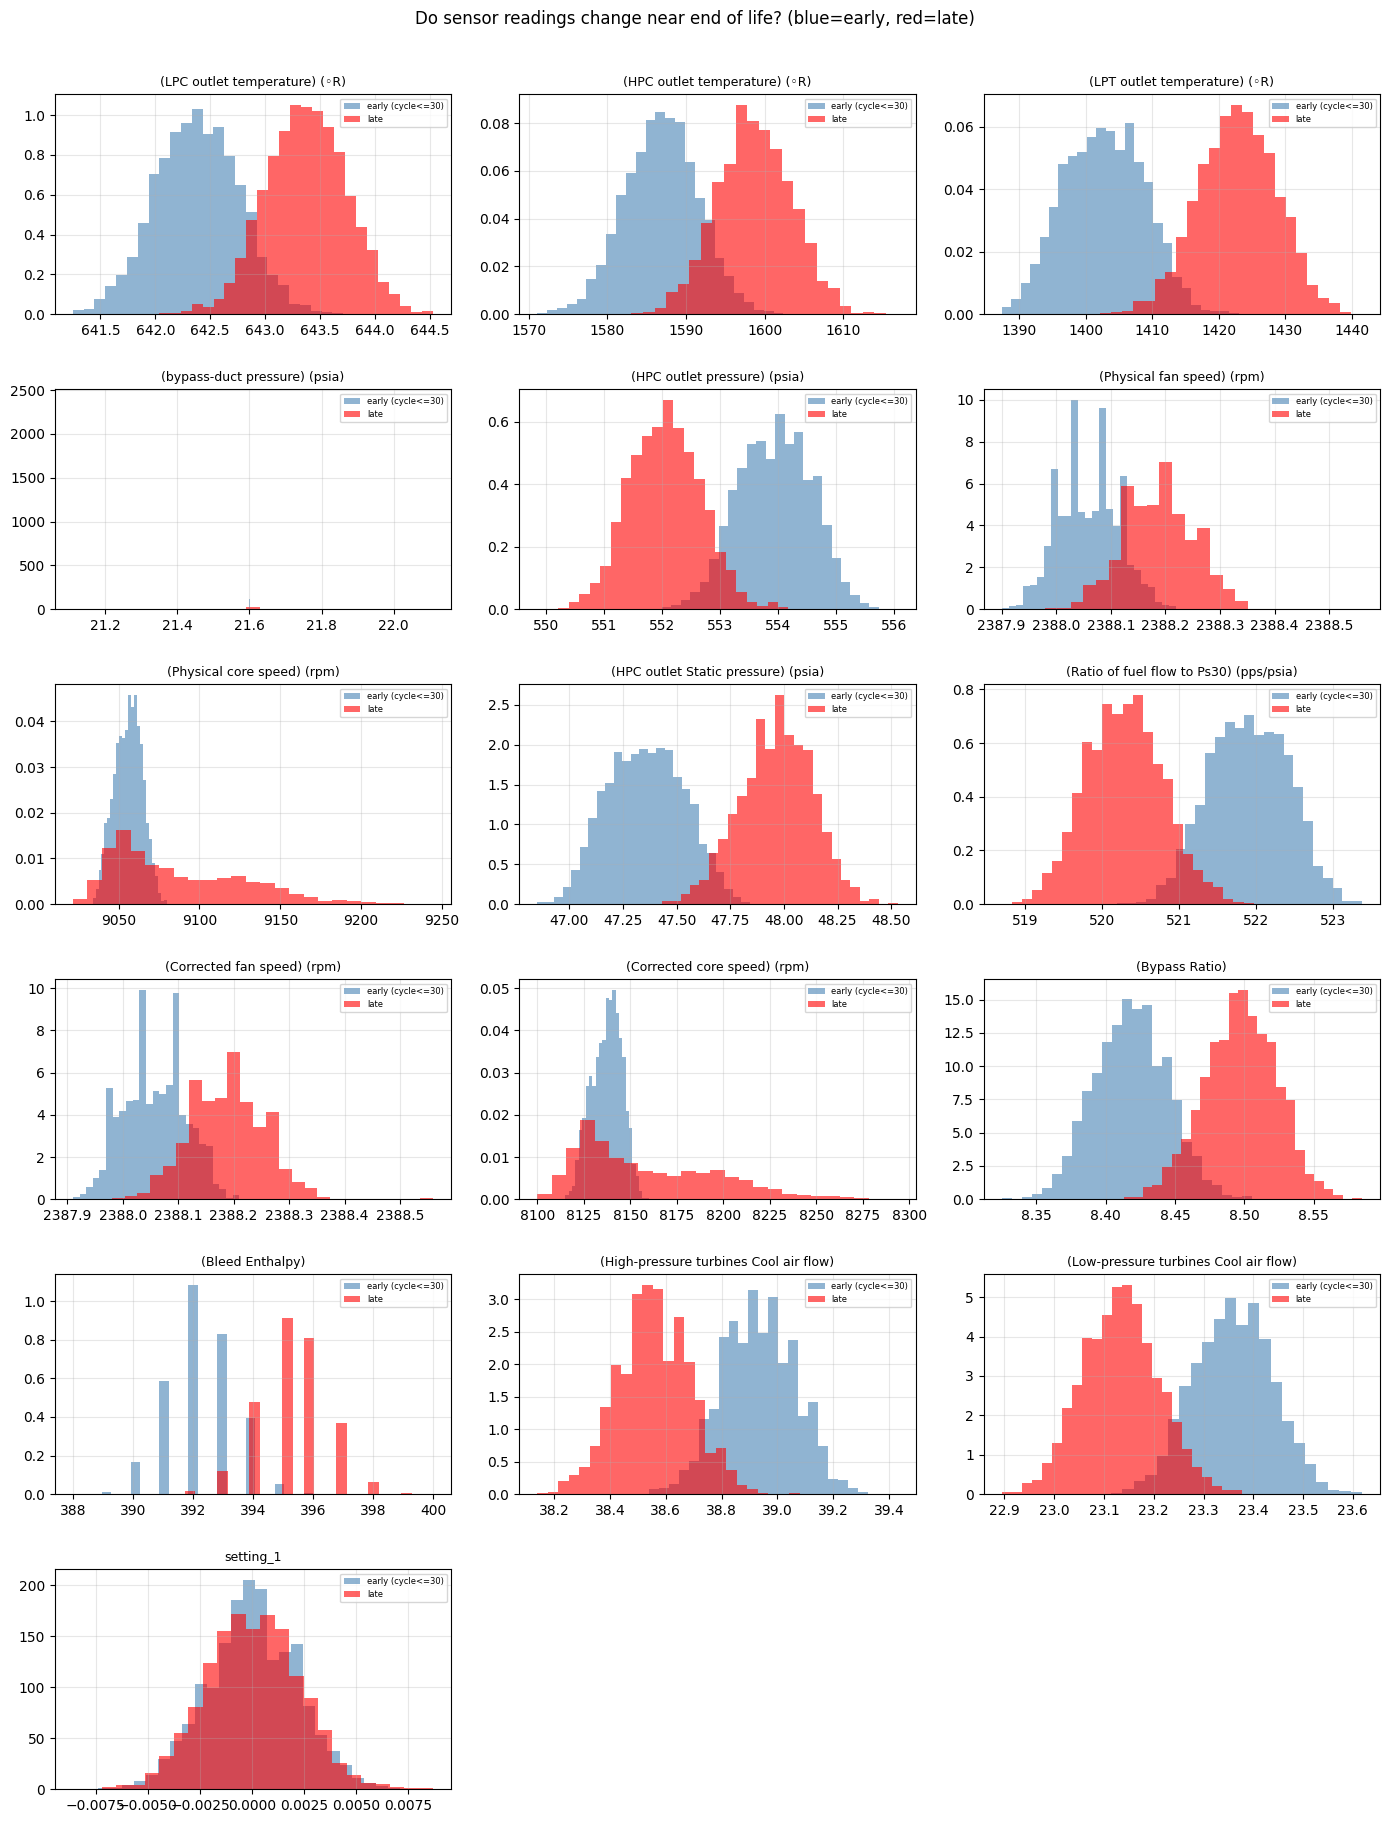

In [ ]:
# plot engine lifetimes
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Engine Lifetime Analysis", fontsize=13)

axes[0].hist(engine_lives['max_cycle'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(engine_lives['max_cycle'].mean(), color='orange', linestyle='--',
                label=f"mean = {engine_lives['max_cycle'].mean():.0f}")
axes[0].set_title("How long do engines last?")
axes[0].set_xlabel("max cycle")
axes[0].set_ylabel("number of engines")
axes[0].legend()

# sort by lifetime
sorted_lives = engine_lives.sort_values('max_cycle', ascending=False).head(30)
axes[1].bar(range(len(sorted_lives)), sorted_lives['max_cycle'], color='steelblue')
axes[1].axhline(engine_lives['max_cycle'].mean(), color='orange', linestyle='--', label='mean')
axes[1].set_title("Top 30 engines by lifetime")
axes[1].set_xlabel("rank")
axes[1].set_ylabel("max cycle")
axes[1].legend()

# cycles per engine scatter
n_cycles = df.groupby('engine').size().reset_index(name='count')
axes[2].scatter(n_cycles['engine'], n_cycles['count'],
                c=n_cycles['count'], cmap='viridis', s=25, alpha=0.7)
axes[2].set_title("Cycles recorded per engine")
axes[2].set_xlabel("engine id")
axes[2].set_ylabel("num cycles")

plt.tight_layout()
plt.savefig("engine_lifetimes.png", dpi=120, bbox_inches='tight')
plt.show()


# look at basic stats for all features
print("\nfeature statistics:")
print(df[feature_cols].describe().T[['mean', 'std', 'min', 'max']])


# correlation heatmap - want to see which sensors are related
fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', center=0, linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.show()


# plot sensor readings over time for a few engines to see if there's a pattern
# picking the 3 engines with the longest lives so we can see the full trend
# using rolling mean (window=15) to smooth out the noise - raw signal is too noisy to read
sample_engines = engine_lives.nlargest(3, 'max_cycle')['engine'].tolist()
n_to_plot = min(6, len(feature_cols))

fig, axes = plt.subplots(n_to_plot, 3, figsize=(16, 3 * n_to_plot))
fig.suptitle("Sensor trends over engine life - rolling mean (window=15)", fontsize=12, y=1.01)

colors = ['steelblue', 'orange', 'green']
for col_idx, eng in enumerate(sample_engines):
    eng_df = df[df['engine'] == eng].sort_values('cycle')
    for row_idx, feat in enumerate(feature_cols[:n_to_plot]):
        ax = axes[row_idx, col_idx]

        raw = eng_df[feat].values
        roll_mean = pd.Series(raw).rolling(window=15, min_periods=1).mean()
        roll_std  = pd.Series(raw).rolling(window=15, min_periods=1).std().fillna(0)

        # plot raw signal faintly in background
        ax.plot(eng_df['cycle'], raw, color=colors[col_idx], linewidth=0.5, alpha=0.25)
        # rolling mean on top
        ax.plot(eng_df['cycle'], roll_mean, color=colors[col_idx], linewidth=1.5, label='rolling mean')
        # shaded band = mean +/- 1 std (shows if variance is increasing over time)
        ax.fill_between(eng_df['cycle'],
                        roll_mean - roll_std,
                        roll_mean + roll_std,
                        color=colors[col_idx], alpha=0.15, label='±1 std')

        ax.set_title(f"engine {eng} - {feat}", fontsize=8)
        ax.set_xlabel("cycle", fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# rolling std over time across all engines (averaged)
# idea: if variance increases near end of life, that's a sign of degradation
# so i want to see if rolling std grows as engines age
ROLL_W = 15
print("\nchecking if sensor variance increases with age...")

sensors_to_check = feature_cols[:4]

fig, axes = plt.subplots(1, len(sensors_to_check), figsize=(15, 4))
fig.suptitle("Does sensor variance increase with age? (rolling std averaged across all engines)", fontsize=11)

for i, feat in enumerate(sensors_to_check):
    ax = axes[i]
    all_roll_std = []

    for eng in df['engine'].unique():
        eng_df = df[df['engine'] == eng].sort_values('cycle').copy()
        eng_df['life_pct_tmp'] = eng_df['cycle'] / eng_df['cycle'].max()
        eng_df['roll_std'] = eng_df[feat].rolling(window=ROLL_W, min_periods=1).std()
        all_roll_std.append(eng_df[['life_pct_tmp', 'roll_std']])

    combined = pd.concat(all_roll_std)
    combined['bin'] = pd.cut(combined['life_pct_tmp'], bins=20)
    binned = combined.groupby('bin', observed=True)['roll_std'].mean()
    bin_centers = [b.mid for b in binned.index]

    ax.plot(bin_centers, binned.values, color='steelblue', linewidth=2)
    ax.fill_between(bin_centers, binned.values, alpha=0.2, color='steelblue')
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("life %")
    ax.set_ylabel("avg rolling std")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rolling_std_vs_age.png", dpi=120, bbox_inches='tight')
plt.show()


# which sensors have the most variation?
sensor_std = df[feature_cols].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sensor_std.index, sensor_std.values, color='steelblue', edgecolor='white')
ax.axhline(sensor_std.mean(), color='red', linestyle='--', label=f'mean std = {sensor_std.mean():.2f}')
ax.set_title("Sensor variability (higher = more useful for detecting changes)")
ax.set_xlabel("sensor")
ax.set_ylabel("std dev")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# check if sensor distributions change from early life vs late life
# this is important - if sensors shift near end of life the model should detect it
early_cycles = df[df['cycle'] <= 30][feature_cols]
late_cycles  = df[df['cycle'] >= df.groupby('engine')['cycle'].transform('max') - 30][feature_cols]

n_cols_grid = 3
n_rows_grid = int(np.ceil(len(feature_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, 3 * n_rows_grid), squeeze=False)
axes = axes.flatten()
fig.suptitle("Do sensor readings change near end of life? (blue=early, red=late)", fontsize=12, y=1.01)

for i, feat in enumerate(feature_cols):
    axes[i].hist(early_cycles[feat].dropna(), bins=25, alpha=0.6, color='steelblue',
                 label='early (cycle<=30)', density=True)
    axes[i].hist(late_cycles[feat].dropna(),  bins=25, alpha=0.6, color='red',
                 label='late', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=6)
    axes[i].grid(alpha=0.3)

# hide empty subplots if number of features isn't divisible by 3
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
scalers = {}
df_scaled = df.copy()

for eng_id in df['engine'].unique():
    mask = df['engine'] == eng_id
    sc = StandardScaler()
    df_scaled.loc[mask, feature_cols] = sc.fit_transform(df.loc[mask, feature_cols])
    scalers[eng_id] = sc  # save it in case i need it later

# clip outliers just in case
df_scaled[feature_cols] = np.clip(df_scaled[feature_cols], -4, 4)

In [ ]:
df_scaled['max_cycle'] = df['max_cycle']
df_scaled['life_pct']  = df['life_pct']

In [ ]:
healthy_scaled = df_scaled[df_scaled['life_pct'] <= 0.30].copy()

In [ ]:
vals = df[feature_cols].values


In [ ]:
SEQ_LEN = 30

def make_sequences(data, seq_len, features, get_meta=False):
    X = []
    meta = []

    for eng in sorted(data['engine'].unique()):
        eng_data = data[data['engine'] == eng].sort_values('cycle')
        vals   = eng_data[features].values
        cycles = eng_data['cycle'].values
        lpct   = eng_data['life_pct'].values

        if len(vals) < seq_len:
            continue  # skip engines with too few cycles

        for i in range(len(vals) - seq_len + 1):
            X.append(vals[i : i + seq_len])
            if get_meta:
                # store which engine this came from and what cycle it ends at
                meta.append((eng, cycles[i + seq_len - 1], lpct[i + seq_len - 1]))

    X = np.array(X, dtype=np.float32)
    if get_meta:
        return X, np.array(meta, dtype=object)
    return X

train_X = make_sequences(healthy_scaled, SEQ_LEN, feature_cols)
test_X, test_meta = make_sequences(df_scaled, SEQ_LEN, feature_cols, get_meta=True)

print("train shape:", train_X.shape)
print("test shape: ", test_X.shape)


train shape: (3244, 30, 16)
test shape:  (17731, 30, 16)


In [ ]:
timesteps  = train_X.shape[1]
n_features = train_X.shape[2]

In [ ]:
inp = Input(shape=(timesteps, n_features))

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 30, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 16)         │         2,064 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,096 (1.03 MB)

 Trainable params: 270,096 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - loss: 0.5348 - val_loss: 0.4725 - learning_rate: 0.0010
Epoch 2/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - loss: 0.4720 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 3/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - loss: 0.4655 - val_loss: 0.4617 - learning_rate: 0.0010
Epoch 4/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - loss: 0.4623 - val_loss: 0.4560 - learning_rate: 0.0010
Epoch 5/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - loss: 0.4596 - val_loss: 0.4534 - learning_rate: 0.0010
Epoch 6/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - loss: 0.4581 - val_loss: 0.4527 - learning_rate: 0.0010
Epoch 7/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - loss: 0.4575 - val_loss: 0.4524 - learning_rate: 0.0010
Epoch 8/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - loss: 0.4570 - val_loss: 0.4521 - learning_rate: 0.0010
Epoch 9/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - loss: 0.4567 - val_loss: 0.4525 - learning_rate: 0.0010
Epo

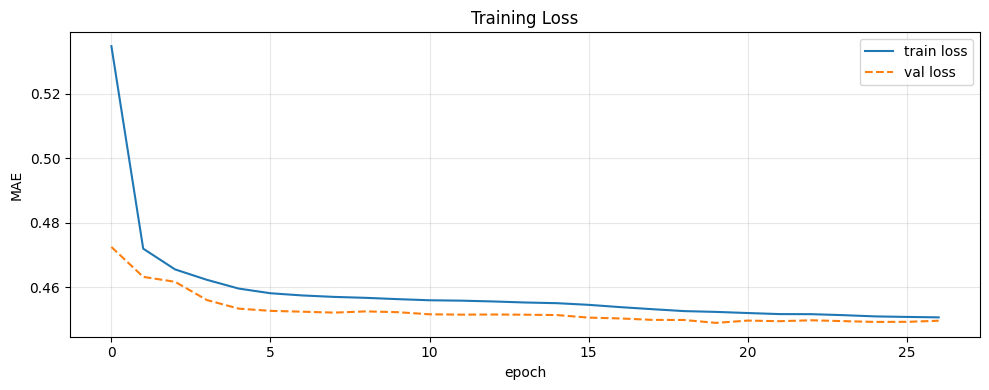


train error: mean=0.4510, std=0.0396
test error:  mean=0.5905, std=0.2158
threshold 90th: 0.5056
threshold 95th: 0.5170
threshold 99th: 0.5421


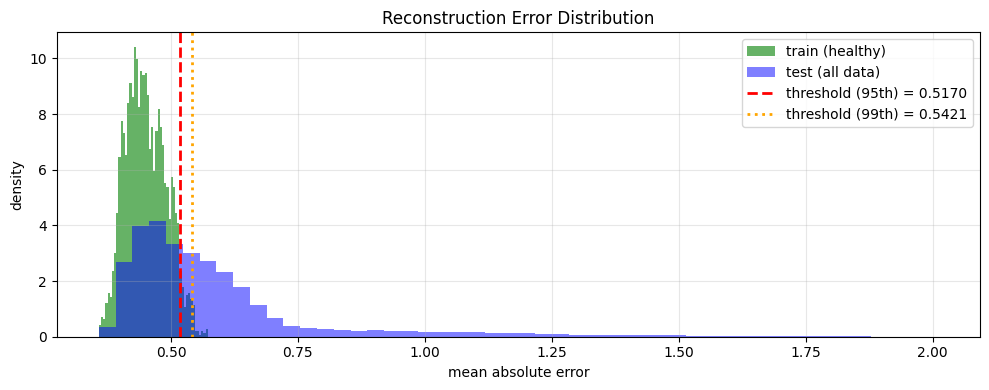


engines with anomalies: 100 / 100

top 10 most anomalous engines:
    engine  max_cycle  mean_error  anomaly_pct  first_anomaly_cycle
7        8        150    0.613181     0.966942                   30
90      91        135    0.668827     0.952830                   30
25      26        199    0.608822     0.947059                   35
15      16        209    0.623767     0.938889                   30
75      76        210    0.611225     0.900552                   30
22      23        168    0.603328     0.884892                   36
21      22        202    0.614342     0.872832                   30
65      66        202    0.610319     0.867052                   30
72      73        213    0.628940     0.831522                   33
11      12        170    0.601544     0.787234                   60


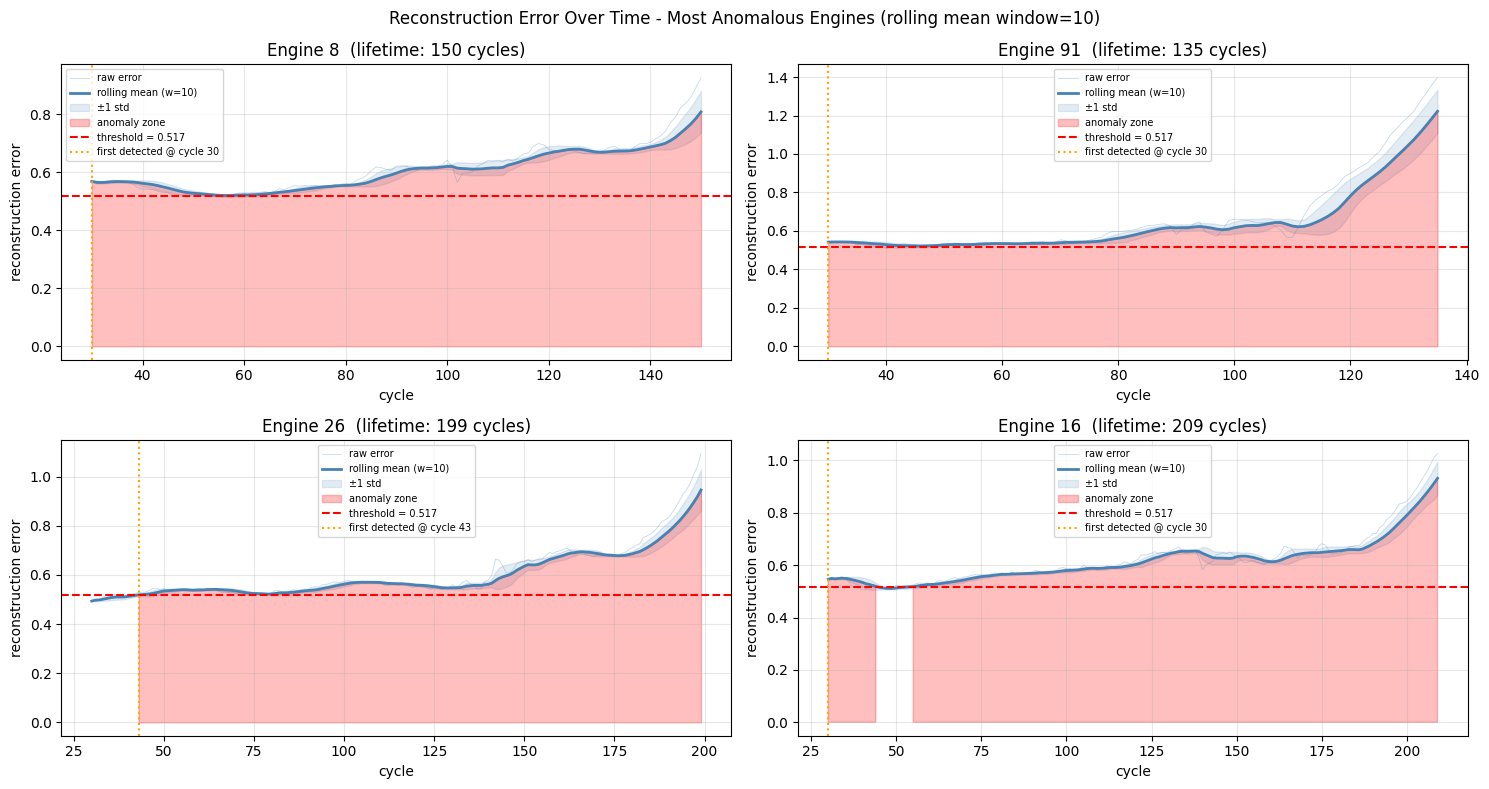

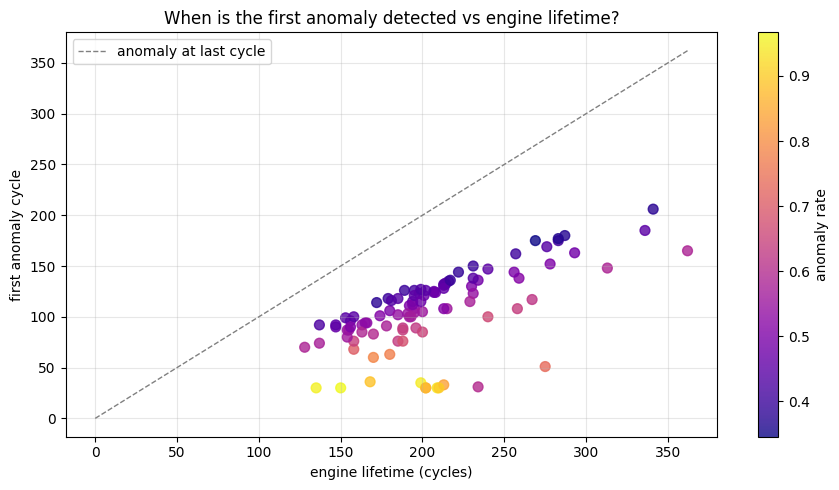

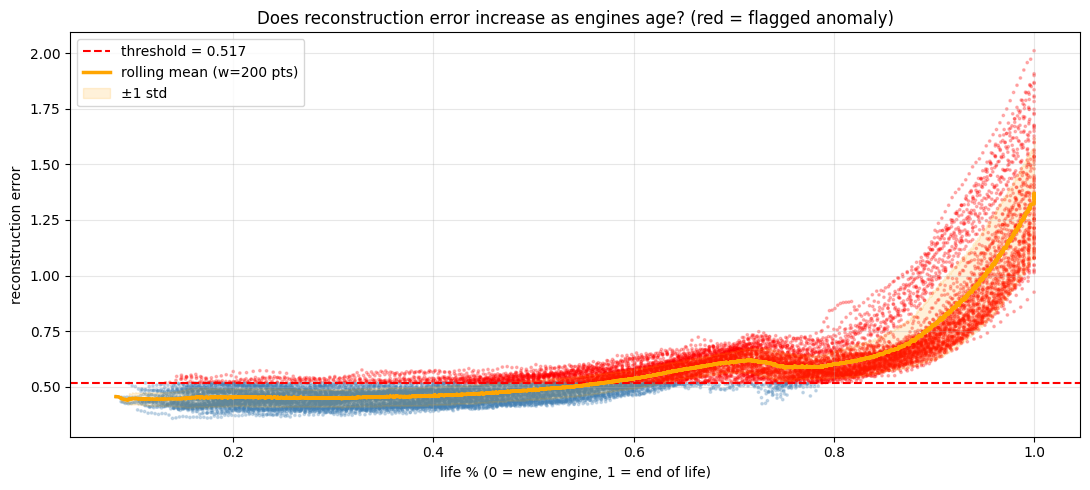

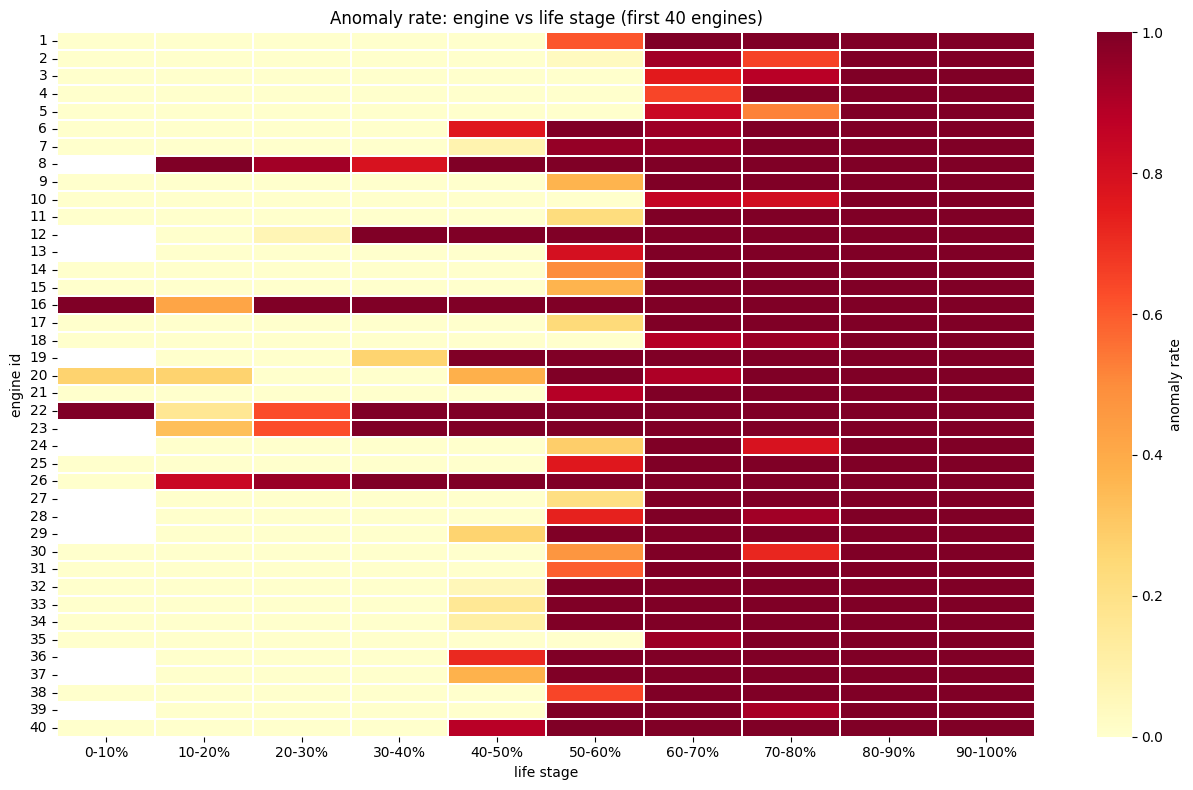


ROC AUC: 0.9801
PR AUC:  0.9279
(note: these use life_pct > 0.85 as a fake label since we dont have real failure labels)


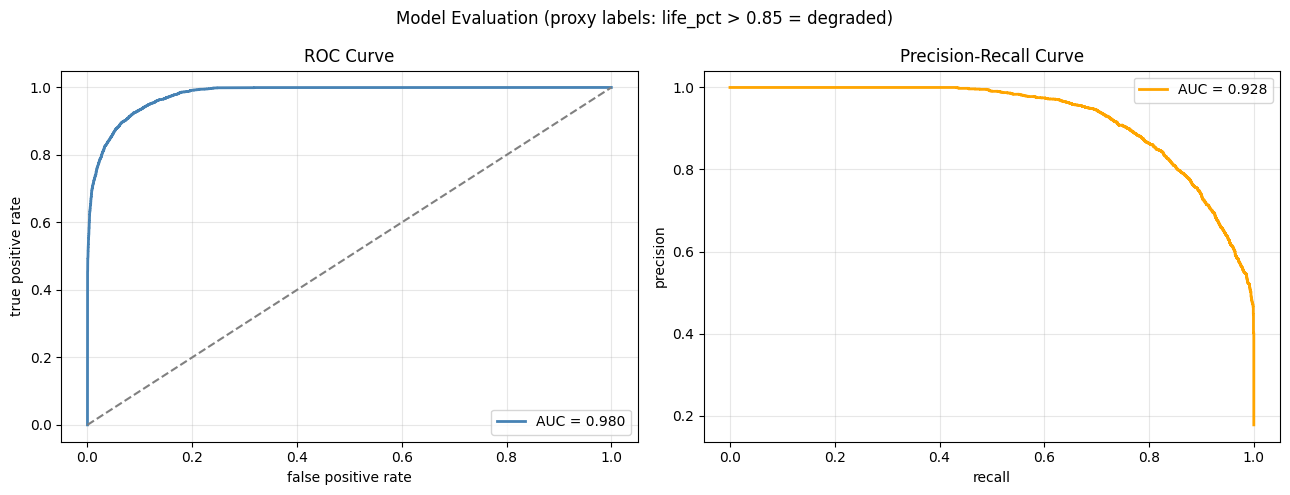


--- RESULTS SUMMARY ---
dataset: 100 engines, 20631 rows, 16 features
sequence length: 30
training sequences (healthy): 3244
test sequences (all): 17731
best val loss: 0.44895
epochs ran: 27

threshold (95th pct of healthy errors): 0.5170
anomalous sequences: 9540 / 17731 (53.8%)
engines with at least 1 anomaly: 100 / 100
avg anomaly onset (% into life): 51.8%

ROC AUC: 0.9801
PR AUC:  0.9279


In [ ]:
# ------------------------------------------------
# build the LSTM autoencoder
# ------------------------------------------------

# architecture:
#   encoder compresses the sequence into a small vector (bottleneck)
#   decoder tries to reconstruct the original sequence from that vector
#   if the engine is healthy, reconstruction should be good
#   if degraded, reconstruction error should be higher

timesteps  = train_X.shape[1]
n_features = train_X.shape[2]

inp = Input(shape=(timesteps, n_features))

# encoder
x = LSTM(128, return_sequences=True)(inp)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=False)(x)  # bottleneck

# repeat the bottleneck so decoder can use it
x = RepeatVector(timesteps)(x)

# decoder (mirrors the encoder)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(128, return_sequences=True)(x)

out = TimeDistributed(Dense(n_features))(x)

model = Model(inp, out)
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mae')
model.summary()


# ------------------------------------------------
# train
# ------------------------------------------------

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_X, train_X,           # autoencoder: input = output
    epochs=80,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

# plot training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='train loss')
ax.plot(history.history['val_loss'], label='val loss', linestyle='--')
ax.set_title("Training Loss")
ax.set_xlabel("epoch")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# compute reconstruction errors and set threshold
# ------------------------------------------------

# get error on training data (healthy only) -> use this to set the threshold
# IMPORTANT: dont use test data to set the threshold, that would be cheating
train_recon  = model.predict(train_X, batch_size=128, verbose=0)
train_errors = np.mean(np.abs(train_X - train_recon), axis=(1, 2))

# get error on all test data
test_recon  = model.predict(test_X, batch_size=128, verbose=0)
test_errors = np.mean(np.abs(test_X - test_recon), axis=(1, 2))

# anything above the 95th percentile of healthy errors = anomaly
# tried 90th and 99th too, 95th seemed like a good balance
threshold_90 = np.percentile(train_errors, 90)
threshold_95 = np.percentile(train_errors, 95)
threshold_99 = np.percentile(train_errors, 99)

print(f"\ntrain error: mean={train_errors.mean():.4f}, std={train_errors.std():.4f}")
print(f"test error:  mean={test_errors.mean():.4f}, std={test_errors.std():.4f}")
print(f"threshold 90th: {threshold_90:.4f}")
print(f"threshold 95th: {threshold_95:.4f}")
print(f"threshold 99th: {threshold_99:.4f}")

# compare error distributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_errors, bins=50, alpha=0.6, color='green',  label='train (healthy)', density=True)
ax.hist(test_errors,  bins=50, alpha=0.5, color='blue',   label='test (all data)', density=True)
ax.axvline(threshold_95, color='red', linestyle='--', linewidth=2, label=f'threshold (95th) = {threshold_95:.4f}')
ax.axvline(threshold_99, color='orange', linestyle=':', linewidth=2, label=f'threshold (99th) = {threshold_99:.4f}')
ax.set_title("Reconstruction Error Distribution")
ax.set_xlabel("mean absolute error")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("error_distribution.png", dpi=120, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# analyze results per engine
# ------------------------------------------------

results = pd.DataFrame(test_meta, columns=['engine', 'cycle', 'life_pct'])
results['error']   = test_errors
results['anomaly'] = results['error'] > threshold_95
results['engine']  = results['engine'].astype(int)
results['cycle']   = results['cycle'].astype(int)
results['life_pct'] = results['life_pct'].astype(float)

# summary per engine
def first_anomaly(x):
    # returns the first cycle where anomaly was detected, NaN if none
    flagged = results.loc[x.index[results.loc[x.index, 'anomaly']], 'cycle']
    return flagged.min() if len(flagged) > 0 else np.nan

engine_summary = results.groupby('engine').agg(
    max_cycle          = ('cycle', 'max'),
    mean_error         = ('error', 'mean'),
    max_error          = ('error', 'max'),
    anomaly_pct        = ('anomaly', 'mean'),
    first_anomaly_cycle = ('cycle', first_anomaly)
).reset_index()

engine_summary['has_anomaly'] = engine_summary['anomaly_pct'] > 0

print(f"\nengines with anomalies: {engine_summary['has_anomaly'].sum()} / {len(engine_summary)}")
print("\ntop 10 most anomalous engines:")
print(engine_summary.sort_values('anomaly_pct', ascending=False).head(10)[
    ['engine', 'max_cycle', 'mean_error', 'anomaly_pct', 'first_anomaly_cycle']
])

# plot 4 worst engines individually
# using rolling mean on error so the signal is smoother and easier to read
# window=10 felt right - not too smooth, not too noisy
worst_engines = engine_summary.sort_values('anomaly_pct', ascending=False).head(4)['engine'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()
fig.suptitle("Reconstruction Error Over Time - Most Anomalous Engines (rolling mean window=10)", fontsize=12)

for i, eng_id in enumerate(worst_engines):
    ax = axes[i]
    edf = results[results['engine'] == eng_id].sort_values('cycle').copy()

    # compute rolling mean and std of the reconstruction error
    edf['roll_mean'] = edf['error'].rolling(window=10, min_periods=1).mean()
    edf['roll_std']  = edf['error'].rolling(window=10, min_periods=1).std().fillna(0)

    # flag anomaly based on rolling mean crossing threshold (less noisy than raw error)
    edf['smooth_anomaly'] = edf['roll_mean'] > threshold_95

    # raw error (faint)
    ax.plot(edf['cycle'], edf['error'], color='steelblue', linewidth=0.6, alpha=0.3, label='raw error')
    # rolling mean
    ax.plot(edf['cycle'], edf['roll_mean'], color='steelblue', linewidth=2, label='rolling mean (w=10)')
    # std band
    ax.fill_between(edf['cycle'],
                    edf['roll_mean'] - edf['roll_std'],
                    edf['roll_mean'] + edf['roll_std'],
                    color='steelblue', alpha=0.15, label='±1 std')
    # shade where rolling mean crosses threshold
    ax.fill_between(edf['cycle'], 0, edf['roll_mean'],
                    where=edf['smooth_anomaly'], color='red', alpha=0.25, label='anomaly zone')
    ax.axhline(threshold_95, color='red', linestyle='--', linewidth=1.5,
               label=f'threshold = {threshold_95:.3f}')

    # first time rolling mean crosses the threshold
    first_smooth = edf[edf['smooth_anomaly']]['cycle'].min()
    if not np.isnan(first_smooth):
        ax.axvline(first_smooth, color='orange', linestyle=':', linewidth=1.5,
                   label=f'first detected @ cycle {int(first_smooth)}')

    ax.set_title(f"Engine {eng_id}  (lifetime: {edf['cycle'].max()} cycles)")
    ax.set_xlabel("cycle")
    ax.set_ylabel("reconstruction error")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("per_engine_errors.png", dpi=120, bbox_inches='tight')
plt.show()


# when does anomaly first get detected relative to end of life?
has_anomaly = engine_summary.dropna(subset=['first_anomaly_cycle'])

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(has_anomaly['max_cycle'], has_anomaly['first_anomaly_cycle'],
                c=has_anomaly['anomaly_pct'], cmap='plasma', s=50, alpha=0.8)
# diagonal line = anomaly only detected at the very end
ax.plot([0, has_anomaly['max_cycle'].max()],
        [0, has_anomaly['max_cycle'].max()],
        color='gray', linestyle='--', linewidth=1, label='anomaly at last cycle')
plt.colorbar(sc, ax=ax, label='anomaly rate')
ax.set_title("When is the first anomaly detected vs engine lifetime?")
ax.set_xlabel("engine lifetime (cycles)")
ax.set_ylabel("first anomaly cycle")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("anomaly_onset.png", dpi=120, bbox_inches='tight')
plt.show()


# error vs how far through the engine's life we are
fig, ax = plt.subplots(figsize=(11, 5))
colors_scatter = ['red' if a else 'steelblue' for a in results['anomaly']]
ax.scatter(results['life_pct'], results['error'], c=colors_scatter, s=3, alpha=0.25)
ax.axhline(threshold_95, color='red', linestyle='--', linewidth=1.5,
           label=f'threshold = {threshold_95:.3f}')

# proper rolling mean - sort by life_pct first then apply rolling window
# this gives a smooth trend line showing how error evolves across the lifecycle
sorted_results = results.sort_values('life_pct').copy()
sorted_results['roll_mean'] = sorted_results['error'].rolling(window=200, min_periods=1).mean()
sorted_results['roll_std']  = sorted_results['error'].rolling(window=200, min_periods=1).std().fillna(0)

ax.plot(sorted_results['life_pct'], sorted_results['roll_mean'],
        color='orange', linewidth=2.5, label='rolling mean (w=200 pts)')
ax.fill_between(sorted_results['life_pct'],
                sorted_results['roll_mean'] - sorted_results['roll_std'],
                sorted_results['roll_mean'] + sorted_results['roll_std'],
                color='orange', alpha=0.15, label='±1 std')

ax.set_title("Does reconstruction error increase as engines age? (red = flagged anomaly)")
ax.set_xlabel("life % (0 = new engine, 1 = end of life)")
ax.set_ylabel("reconstruction error")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("error_vs_lifepct.png", dpi=120, bbox_inches='tight')
plt.show()


# heatmap of anomaly rate by engine and life stage
results['life_bin'] = pd.cut(results['life_pct'], bins=10,
                              labels=[f"{i*10}-{(i+1)*10}%" for i in range(10)])

sample_eng = sorted(results['engine'].unique())[:40]  # show first 40 engines
hm_pivot = (results[results['engine'].isin(sample_eng)]
            .groupby(['engine', 'life_bin'])['anomaly']
            .mean()
            .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(hm_pivot, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'anomaly rate'}, vmin=0, vmax=1)
ax.set_title("Anomaly rate: engine vs life stage (first 40 engines)")
ax.set_xlabel("life stage")
ax.set_ylabel("engine id")
plt.tight_layout()
plt.savefig("anomaly_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# evaluation
# ------------------------------------------------

# i dont have actual labels for when engines fail
# so i'm using life_pct > 0.85 as a proxy for "degraded"
# its not perfect but gives some idea of model quality

results['true_label'] = (results['life_pct'] > 0.85).astype(int)

roc_auc_val = roc_auc_score(results['true_label'], results['error'])
prec, rec, _ = precision_recall_curve(results['true_label'], results['error'])
pr_auc_val   = auc(rec, prec)

print(f"\nROC AUC: {roc_auc_val:.4f}")
print(f"PR AUC:  {pr_auc_val:.4f}")
print("(note: these use life_pct > 0.85 as a fake label since we dont have real failure labels)")

fpr, tpr, _ = roc_curve(results['true_label'], results['error'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Evaluation (proxy labels: life_pct > 0.85 = degraded)", fontsize=12)

axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, color='orange', linewidth=2, label=f'AUC = {pr_auc_val:.3f}')
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# final summary
# ------------------------------------------------

print("\n--- RESULTS SUMMARY ---")
print(f"dataset: {df['engine'].nunique()} engines, {len(df)} rows, {len(feature_cols)} features")
print(f"sequence length: {SEQ_LEN}")
print(f"training sequences (healthy): {len(train_X)}")
print(f"test sequences (all): {len(test_X)}")
print(f"best val loss: {min(history.history['val_loss']):.5f}")
print(f"epochs ran: {len(history.history['loss'])}")
print(f"\nthreshold (95th pct of healthy errors): {threshold_95:.4f}")
print(f"anomalous sequences: {results['anomaly'].sum()} / {len(results)} ({results['anomaly'].mean()*100:.1f}%)")
print(f"engines with at least 1 anomaly: {engine_summary['has_anomaly'].sum()} / {len(engine_summary)}")
print(f"avg anomaly onset (% into life): {(has_anomaly['first_anomaly_cycle'] / has_anomaly['max_cycle']).mean()*100:.1f}%")
print(f"\nROC AUC: {roc_auc_val:.4f}")
print(f"PR AUC:  {pr_auc_val:.4f}")


